# EDA — House Prices

Разведочный анализ данных для соревнования Kaggle House Prices.  
Цель: понять структуру датасета, выявить пропуски, выбросы и ключевые признаки.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('../data/train.csv')

## Обзор датасета

Загружаем `train.csv` и проводим первичный осмотр: размерность, типы, пропуски, корреляции.

array([[<Axes: title={'center': 'Id'}>,
        <Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>],
       [<Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>],
       [<Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>],
       [<Axes: title={'center': 'BsmtHalfBath'}>,
        <Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,

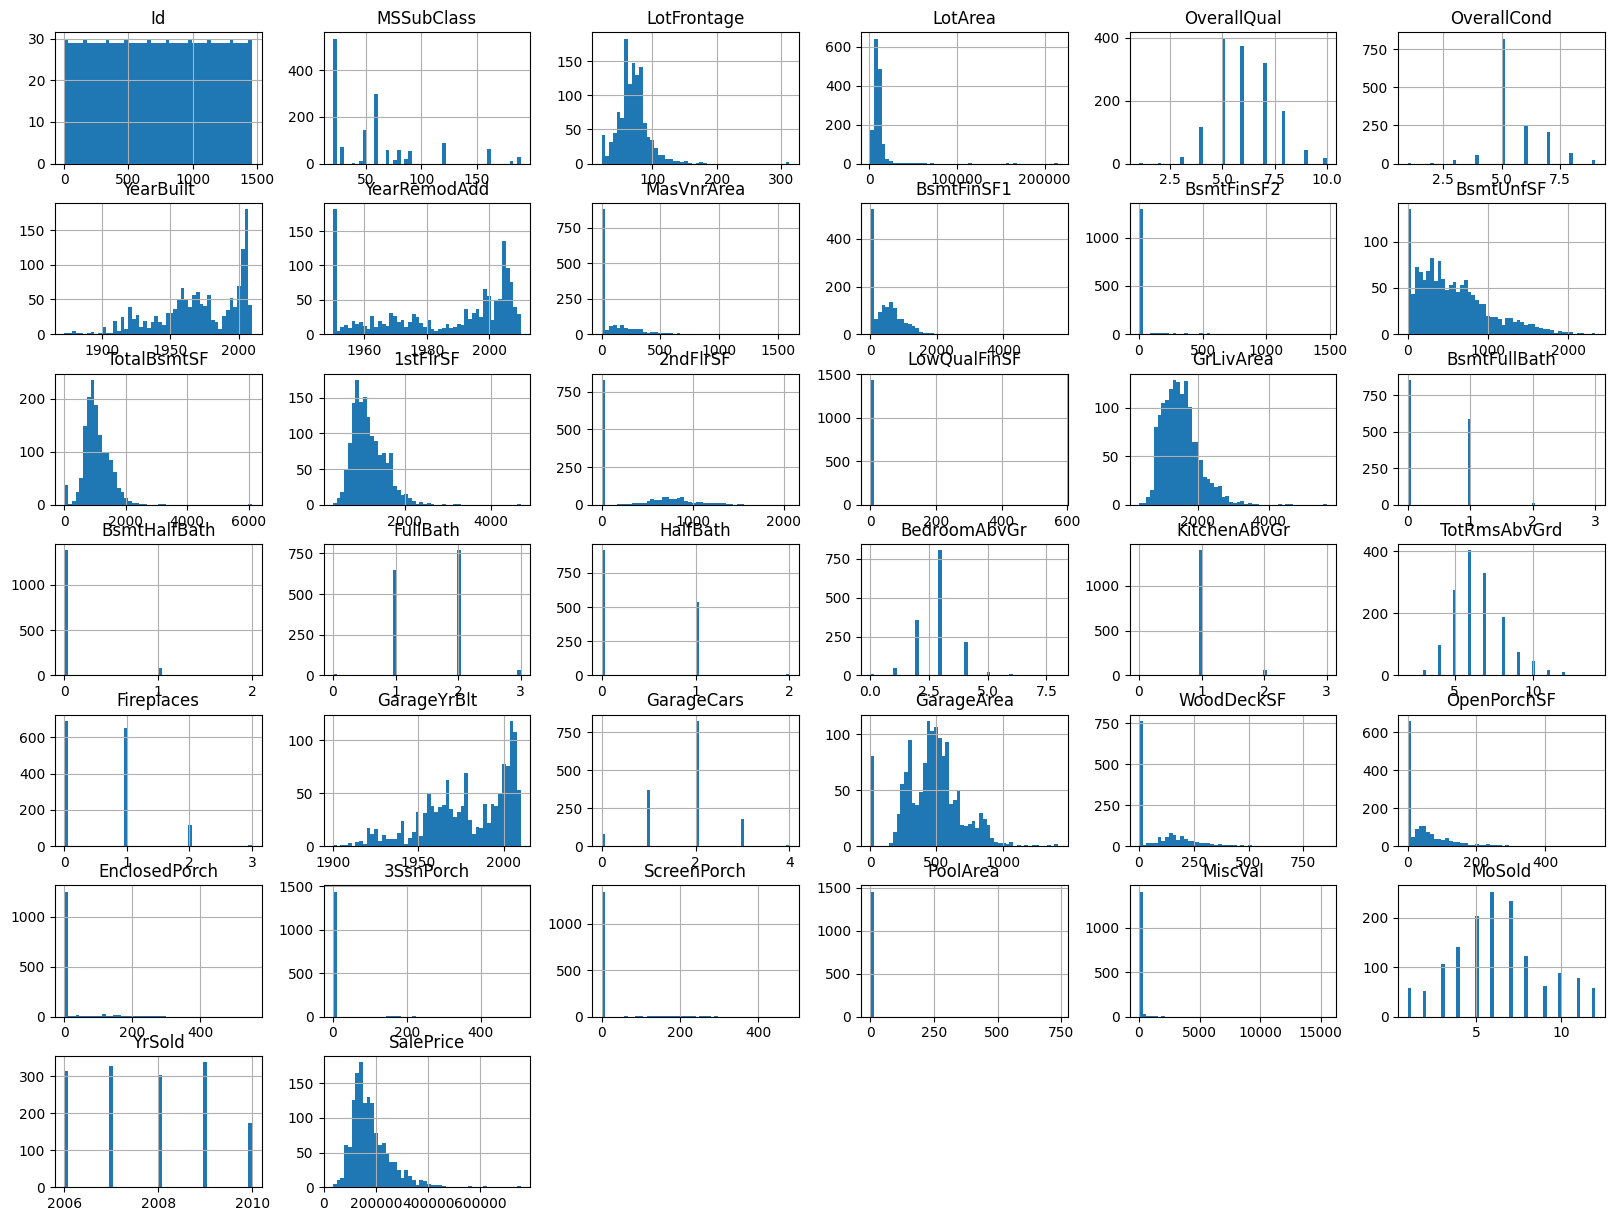

In [2]:
df = pd.read_csv('../data/train.csv')
df.hist(bins=50, figsize=(20,15))

**Вывод:** большинство числовых признаков скошены вправо — особенно заметно у `SalePrice`, `GrLivArea`, `LotArea`.  
Это мотивирует применение `log1p`-трансформации к таргету и к признакам.

In [3]:
df.dtypes.value_counts()

str        43
int64      35
float64     3
Name: count, dtype: int64

In [4]:
df.isna().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

**Вывод по пропускам:** `PoolQC`, `MiscFeature`, `Alley`, `Fence` — NaN означает отсутствие объекта (нет бассейна, нет забора), а не реальный пропуск.  
В `features.py` они заполняются строкой `"None"` или `0` в `fill_na_domain()`.

In [5]:
# 1. Считаем корреляцию
corr_matrix = df.corr(numeric_only=True)

# 2. Разворачиваем матрицу в список пар (признак_1, признак_2)
corr_pairs = corr_matrix.unstack()

# 3. Убираем корреляции признаков самих с собой (где значение равно 1.0)
corr_pairs = corr_pairs[corr_pairs != 1.0]

# 4. Убираем дубликаты (т.к. корреляция A с B равна корреляции B с A)
# Для этого отсортируем индексы перед удалением дубликатов
corr_pairs = corr_pairs.loc[
    corr_pairs.index.map(lambda x: tuple(sorted(x))).drop_duplicates()
]

# 5. Сортируем по убыванию модуля корреляции (чтобы сильные отрицательные тоже были в топе)
sorted_pairs = corr_pairs.abs().sort_values(ascending=False)

# Выводим топ-15 самых сильных связей
print("Топ самых сильных корреляций между признаками:")
print(sorted_pairs.head(15))

Топ самых сильных корреляций между признаками:
GarageArea    GarageCars      0.882475
GarageYrBlt   YearBuilt       0.825667
GrLivArea     TotRmsAbvGrd    0.825489
1stFlrSF      TotalBsmtSF     0.819530
OverallQual   SalePrice       0.790982
GrLivArea     SalePrice       0.708624
2ndFlrSF      GrLivArea       0.687501
BedroomAbvGr  TotRmsAbvGrd    0.676620
BsmtFinSF1    BsmtFullBath    0.649212
GarageYrBlt   YearRemodAdd    0.642277
GarageCars    SalePrice       0.640409
FullBath      GrLivArea       0.630012
GarageArea    SalePrice       0.623431
2ndFlrSF      TotRmsAbvGrd    0.616423
SalePrice     TotalBsmtSF     0.613581
dtype: float64


**Вывод по корреляциям:** топ признаков по связи с `SalePrice`:  
- `OverallQual` (~0.79) — общее качество постройки  
- `GrLivArea` (~0.71) — жилая площадь над землёй  
- `GarageCars` / `GarageArea` (~0.64) — размер гаража  

На основе этого создан составной признак `Qual_x_Area = OverallQual * GrLivArea`.

In [6]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
df['OverallQual']

0       7
1       6
2       7
3       7
4       8
       ..
1455    6
1456    6
1457    7
1458    5
1459    5
Name: OverallQual, Length: 1460, dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.shape

(1460, 81)

**Вывод:** датасет содержит **1460 объектов** и **80 признаков** (79 + `SalePrice`).  
Смесь числовых (int/float) и категориальных (object) признаков требует разного препроцессинга для ML и DL пайплайнов.

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [11]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


**Вывод по describe:** `SalePrice` в диапазоне 34 900–755 000, медиана ~163 000.  
Большой разброс подтверждает необходимость логарифмического таргета — модель штрафует относительные ошибки (дорогой дом ± 10% ≈ дешёвый дом ± 10%).

In [12]:
df.memory_usage()

Index              132
Id               11680
MSSubClass       11680
MSZoning         11680
LotFrontage      11680
                 ...  
MoSold           11680
YrSold           11680
SaleType         11680
SaleCondition    11680
SalePrice        11680
Length: 82, dtype: int64

In [13]:
for col in df.columns:
    print(f"Колонка {col} имеет {df[col].nunique()} уникальных значений")

Колонка Id имеет 1460 уникальных значений
Колонка MSSubClass имеет 15 уникальных значений
Колонка MSZoning имеет 5 уникальных значений
Колонка LotFrontage имеет 110 уникальных значений
Колонка LotArea имеет 1073 уникальных значений
Колонка Street имеет 2 уникальных значений
Колонка Alley имеет 2 уникальных значений
Колонка LotShape имеет 4 уникальных значений
Колонка LandContour имеет 4 уникальных значений
Колонка Utilities имеет 2 уникальных значений
Колонка LotConfig имеет 5 уникальных значений
Колонка LandSlope имеет 3 уникальных значений
Колонка Neighborhood имеет 25 уникальных значений
Колонка Condition1 имеет 9 уникальных значений
Колонка Condition2 имеет 8 уникальных значений
Колонка BldgType имеет 5 уникальных значений
Колонка HouseStyle имеет 8 уникальных значений
Колонка OverallQual имеет 10 уникальных значений
Колонка OverallCond имеет 9 уникальных значений
Колонка YearBuilt имеет 112 уникальных значений
Колонка YearRemodAdd имеет 61 уникальных значений
Колонка RoofStyle име

## Визуализации

Графический анализ целевой переменной, пропусков, корреляций и распределений признаков.

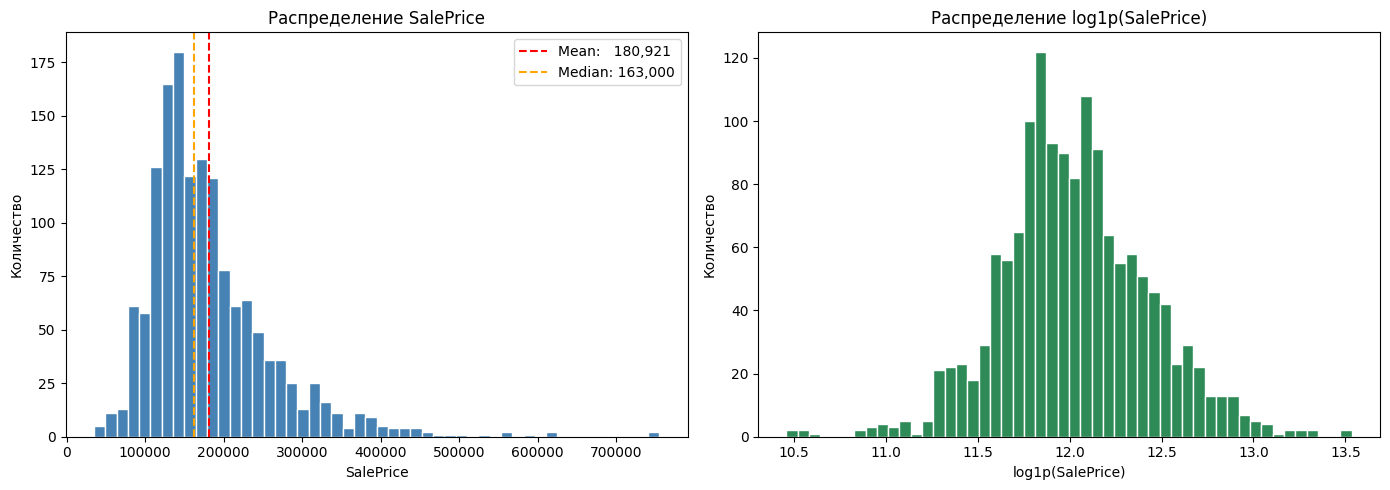

Skewness SalePrice:        1.8829
Skewness log1p(SalePrice): 0.1213


In [14]:
# Распределение целевой переменной SalePrice
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение SalePrice')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Количество')
axes[0].axvline(df['SalePrice'].mean(),   color='red',    linestyle='--',
                label=f"Mean:   {df['SalePrice'].mean():,.0f}")
axes[0].axvline(df['SalePrice'].median(), color='orange', linestyle='--',
                label=f"Median: {df['SalePrice'].median():,.0f}")
axes[0].legend()

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Распределение log1p(SalePrice)')
axes[1].set_xlabel('log1p(SalePrice)')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

print(f"Skewness SalePrice:        {df['SalePrice'].skew():.4f}")
print(f"Skewness log1p(SalePrice): {np.log1p(df['SalePrice']).skew():.4f}")


**Вывод:** `SalePrice` имеет правостороннюю асимметрию (skew ≈ 1.88).  
После `log1p`-трансформации распределение близко к нормальному (skew ≈ 0.12).  
Это снижает влияние выбросов и позволяет оптимизировать RMSLE через обычный RMSE.

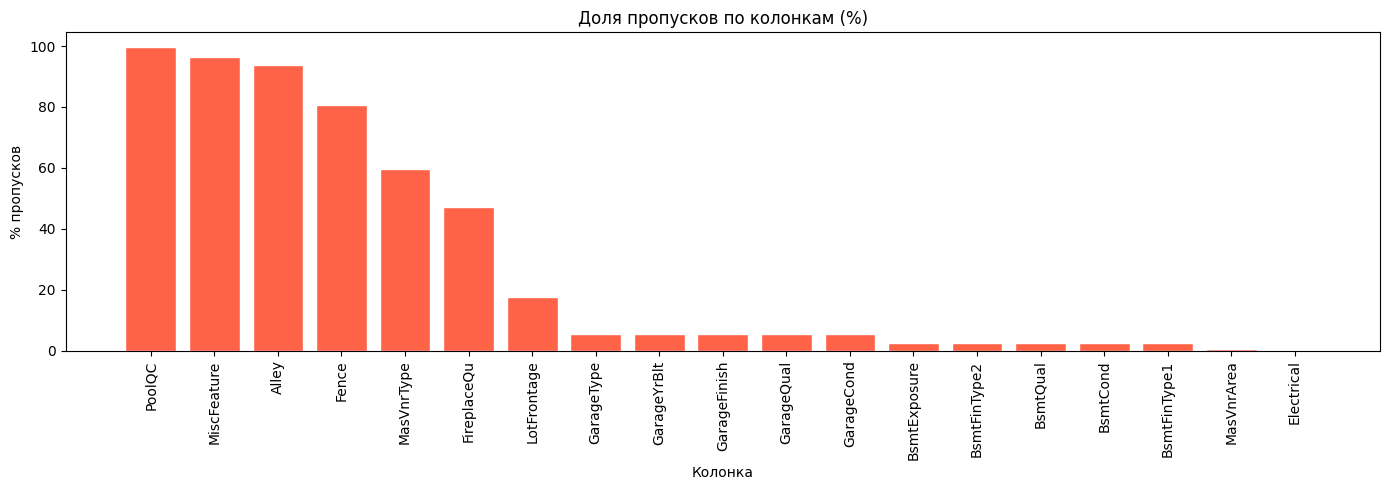

Колонок с пропусками: 19
PoolQC          99.52
MiscFeature     96.30
Alley           93.77
Fence           80.75
MasVnrType      59.73
FireplaceQu     47.26
LotFrontage     17.74
GarageType       5.55
GarageYrBlt      5.55
GarageFinish     5.55
GarageQual       5.55
GarageCond       5.55
BsmtExposure     2.60
BsmtFinType2     2.60
BsmtQual         2.53
BsmtCond         2.53
BsmtFinType1     2.53
MasVnrArea       0.55
Electrical       0.07


In [15]:
# Визуализация пропусков
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(missing.index, missing_pct.values, color='tomato', edgecolor='white')
ax.set_title('Доля пропусков по колонкам (%)')
ax.set_xlabel('Колонка')
ax.set_ylabel('% пропусков')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

print(f'Колонок с пропусками: {len(missing)}')
print(missing_pct.to_string())


**Вывод:** признаки с наибольшим числом пропусков (`PoolQC`, `MiscFeature`, `Alley`) отсутствуют у большинства домов — NaN = "нет объекта".  
`LotFrontage` (~18% пропусков) заполняется медианой по `Neighborhood` в `fill_na_domain()`.

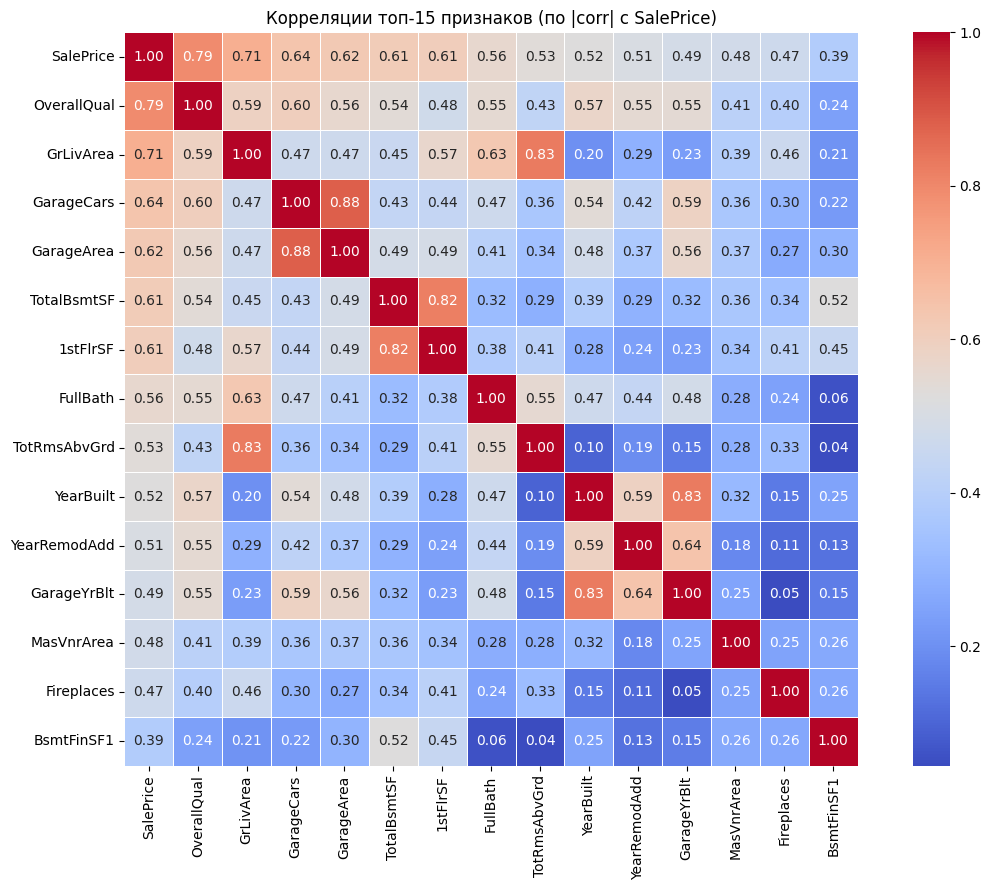

In [16]:
# Тепловая карта корреляций топ-15 числовых признаков с SalePrice
corr = df.corr(numeric_only=True)
top_feats = corr['SalePrice'].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 9))
sns.heatmap(
    df[top_feats].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    square=True, linewidths=0.5,
)
plt.title('Корреляции топ-15 признаков (по |corr| с SalePrice)')
plt.tight_layout()
plt.show()


**Вывод:** тепловая карта показывает мультиколлинеарность: `TotalBsmtSF` и `1stFlrSF` (r ≈ 0.82), `GarageCars` и `GarageArea` (r ≈ 0.88).  
Для Ridge это несущественно (L2-регуляризация), для boosting-моделей — тоже.  
Агрегат `TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF` объединяет коррелирующие площади.

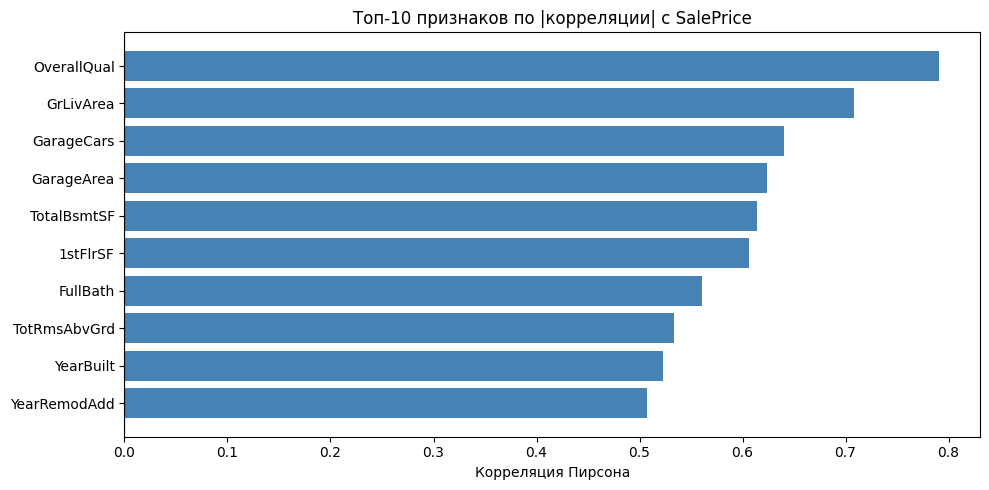

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101


In [17]:
# Топ-10 числовых признаков по корреляции с SalePrice
corr_with_target = df.corr(numeric_only=True)['SalePrice'].drop('SalePrice')
top10 = corr_with_target.abs().sort_values(ascending=False).head(10)

colors = ['steelblue' if corr_with_target[c] > 0 else 'tomato' for c in top10.index]
plt.figure(figsize=(10, 5))
plt.barh(top10.index[::-1], corr_with_target[top10.index[::-1]], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Топ-10 признаков по |корреляции| с SalePrice')
plt.xlabel('Корреляция Пирсона')
plt.tight_layout()
plt.show()

print(corr_with_target.abs().sort_values(ascending=False).head(10).to_string())


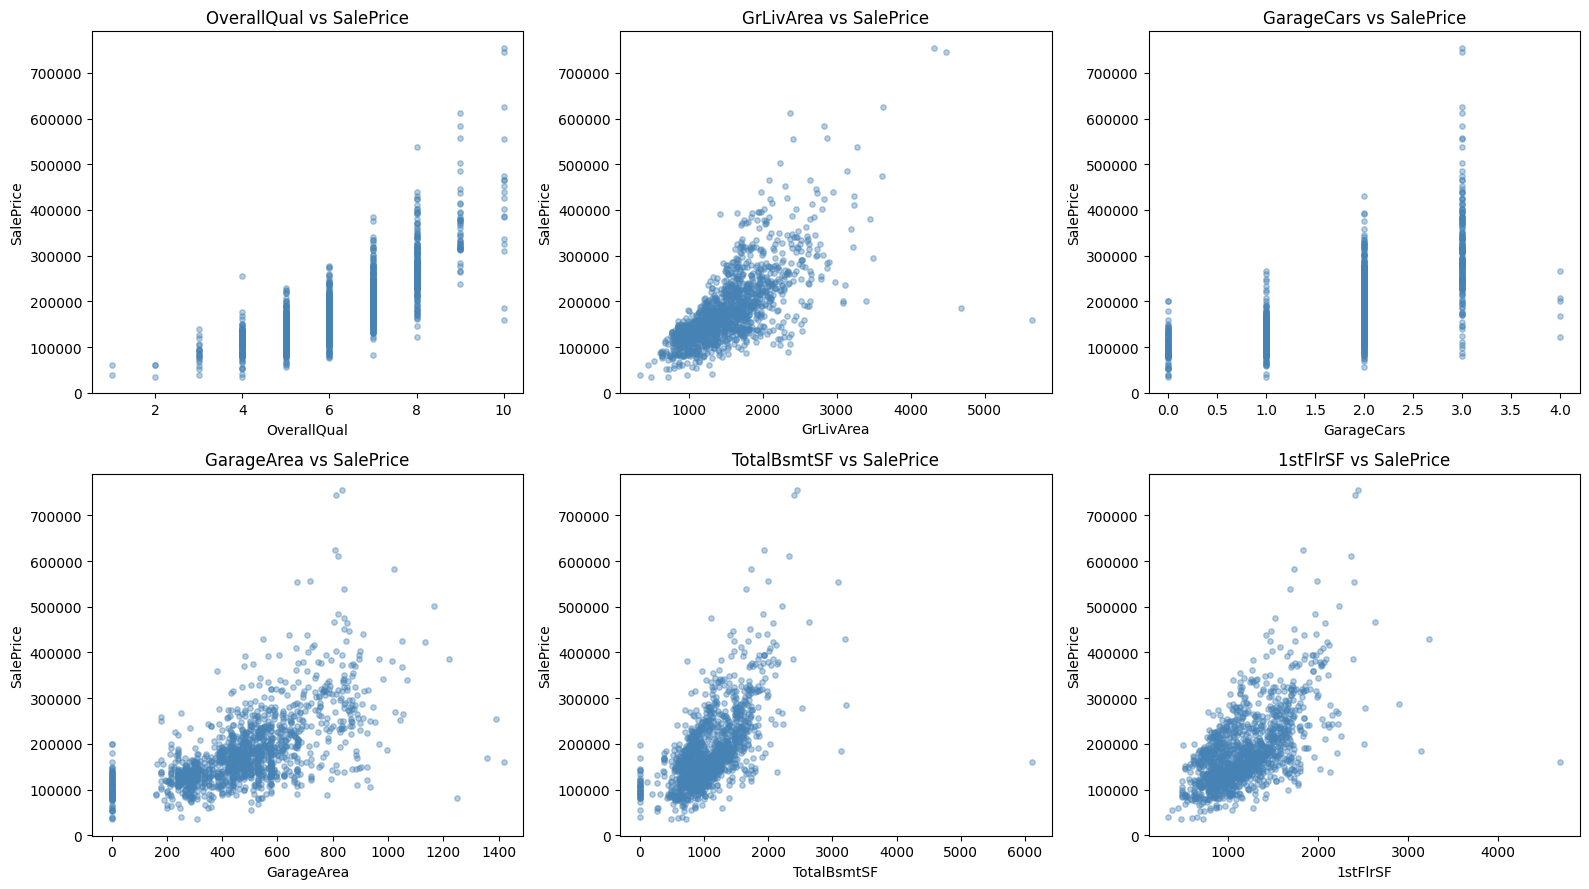

In [18]:
# Scatter-plots: топ-6 числовых признаков vs SalePrice
top6_num = (
    df.corr(numeric_only=True)['SalePrice']
    .drop('SalePrice').abs()
    .sort_values(ascending=False)
    .head(6).index
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.flat, top6_num):
    ax.scatter(df[feat], df['SalePrice'], alpha=0.4, s=15, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('SalePrice')
    ax.set_title(f'{feat} vs SalePrice')
plt.tight_layout()
plt.show()


**Вывод:** на scatter-plots виден кластер выбросов — большой `GrLivArea` (> 4000) при низкой цене.  
Эти точки удаляются в `data.py` функцией `load_data()` — они искажали обучение модели.

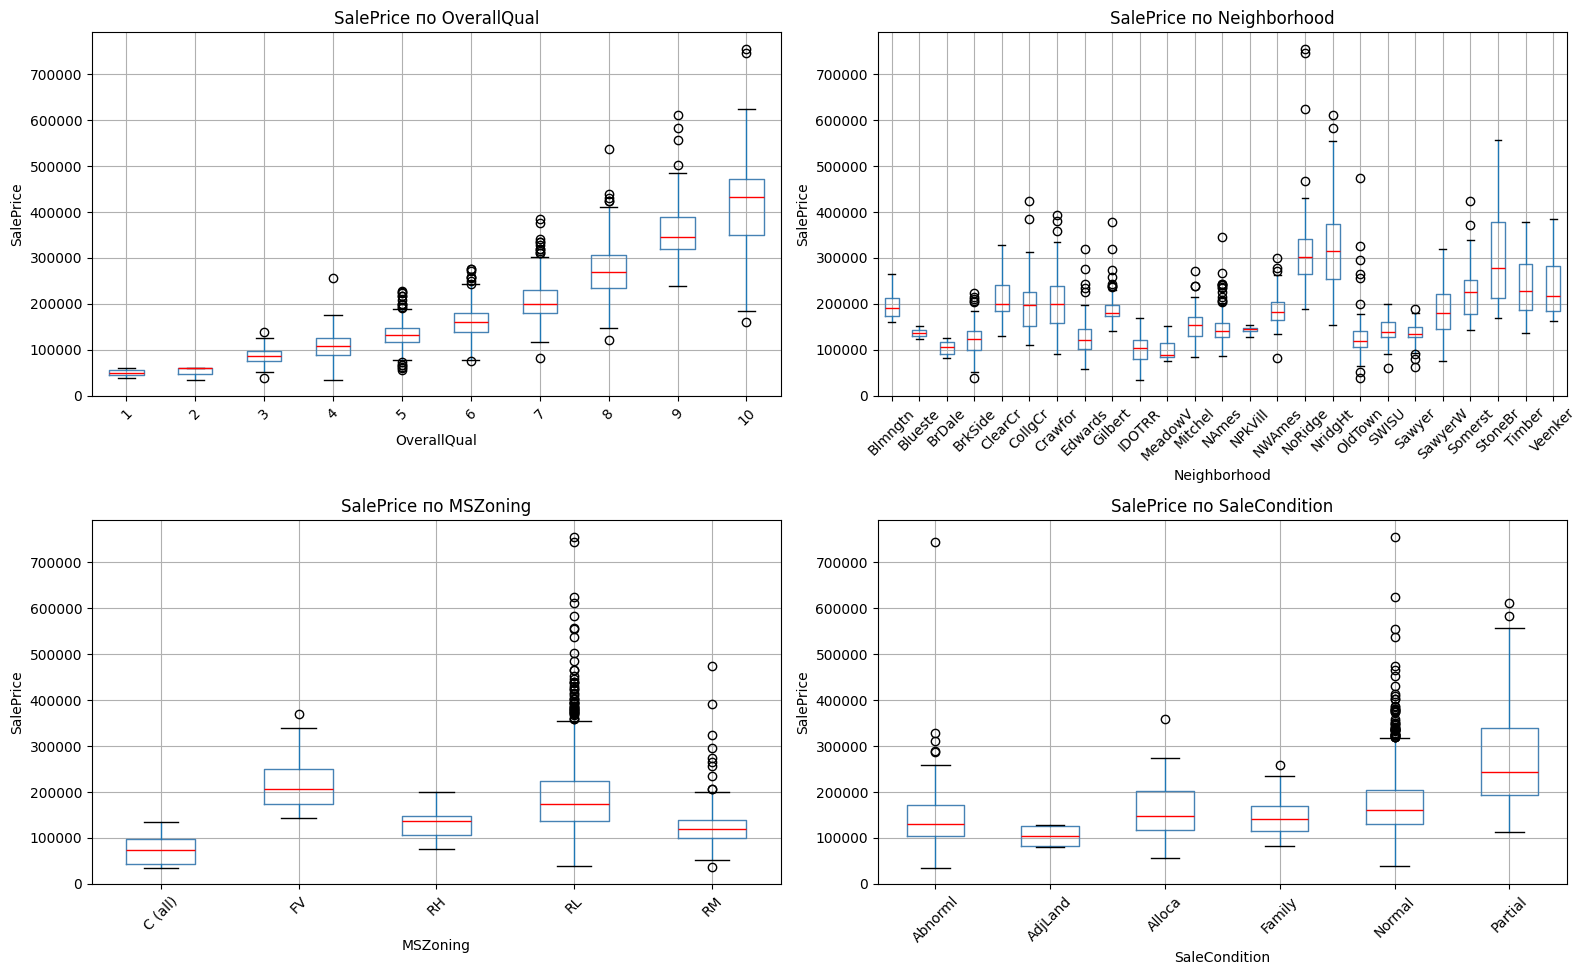

In [19]:
# Box-plots: ключевые категориальные признаки vs SalePrice
cat_feats = ['OverallQual', 'Neighborhood', 'MSZoning', 'SaleCondition']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, feat in zip(axes.flat, cat_feats):
    order = df.groupby(feat)['SalePrice'].median().sort_values().index
    df.boxplot(column='SalePrice', by=feat, ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red'))
    ax.set_title(f'SalePrice по {feat}')
    ax.set_xlabel(feat)
    ax.set_ylabel('SalePrice')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('')
plt.tight_layout()
plt.show()


**Вывод:** `OverallQual` имеет монотонную связь с `SalePrice` — качество 9–10 даёт медианную цену в 3–4 раза выше качества 4–5.  
В `features.py` качественные признаки (`ExterQual`, `KitchenQual` и др.) кодируются в порядковые числа 0–5 через `QUAL_MAP`.

Признаков с |skew| > 1.0: 20
Признаков с |skew| > 0.75: 22


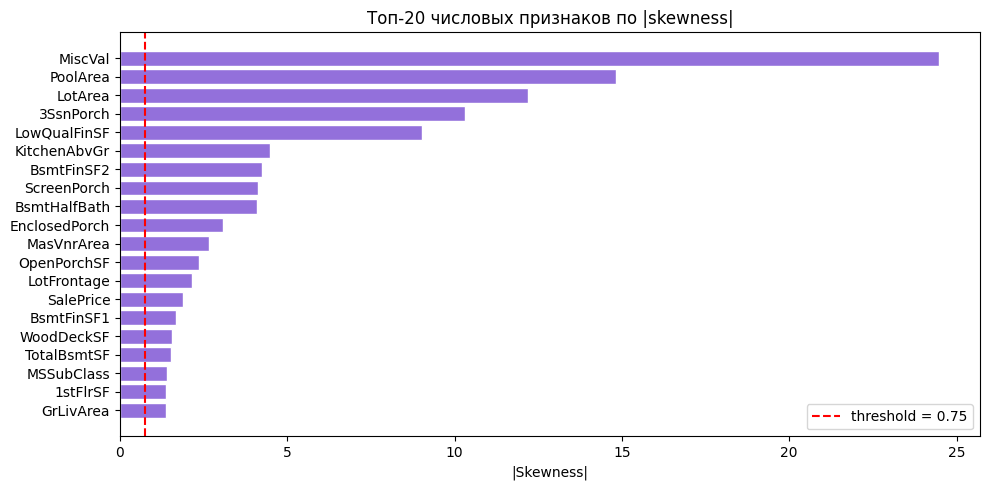

In [20]:
# Скошенность (skewness) числовых признаков
num_cols = df.select_dtypes(include='number').columns.drop('Id', errors='ignore')
skewness = df[num_cols].skew().abs().sort_values(ascending=False)

print(f'Признаков с |skew| > 1.0: {(skewness > 1.0).sum()}')
print(f'Признаков с |skew| > 0.75: {(skewness > 0.75).sum()}')

# Топ-20 самых скошенных
top_skew = skewness.head(20)
plt.figure(figsize=(10, 5))
plt.barh(top_skew.index[::-1], top_skew.values[::-1], color='mediumpurple', edgecolor='white')
plt.axvline(0.75, color='red', linestyle='--', label='threshold = 0.75')
plt.title('Топ-20 числовых признаков по |skewness|')
plt.xlabel('|Skewness|')
plt.legend()
plt.tight_layout()
plt.show()


**Вывод:** многие числовые признаки имеют высокую асимметрию (|skew| > 0.75).  
В `features.py` функция `get_skewed_columns()` находит такие признаки на train и применяет к ним `log1p`. Список фиксируется на train и передаётся на test — чтобы избежать data leakage.

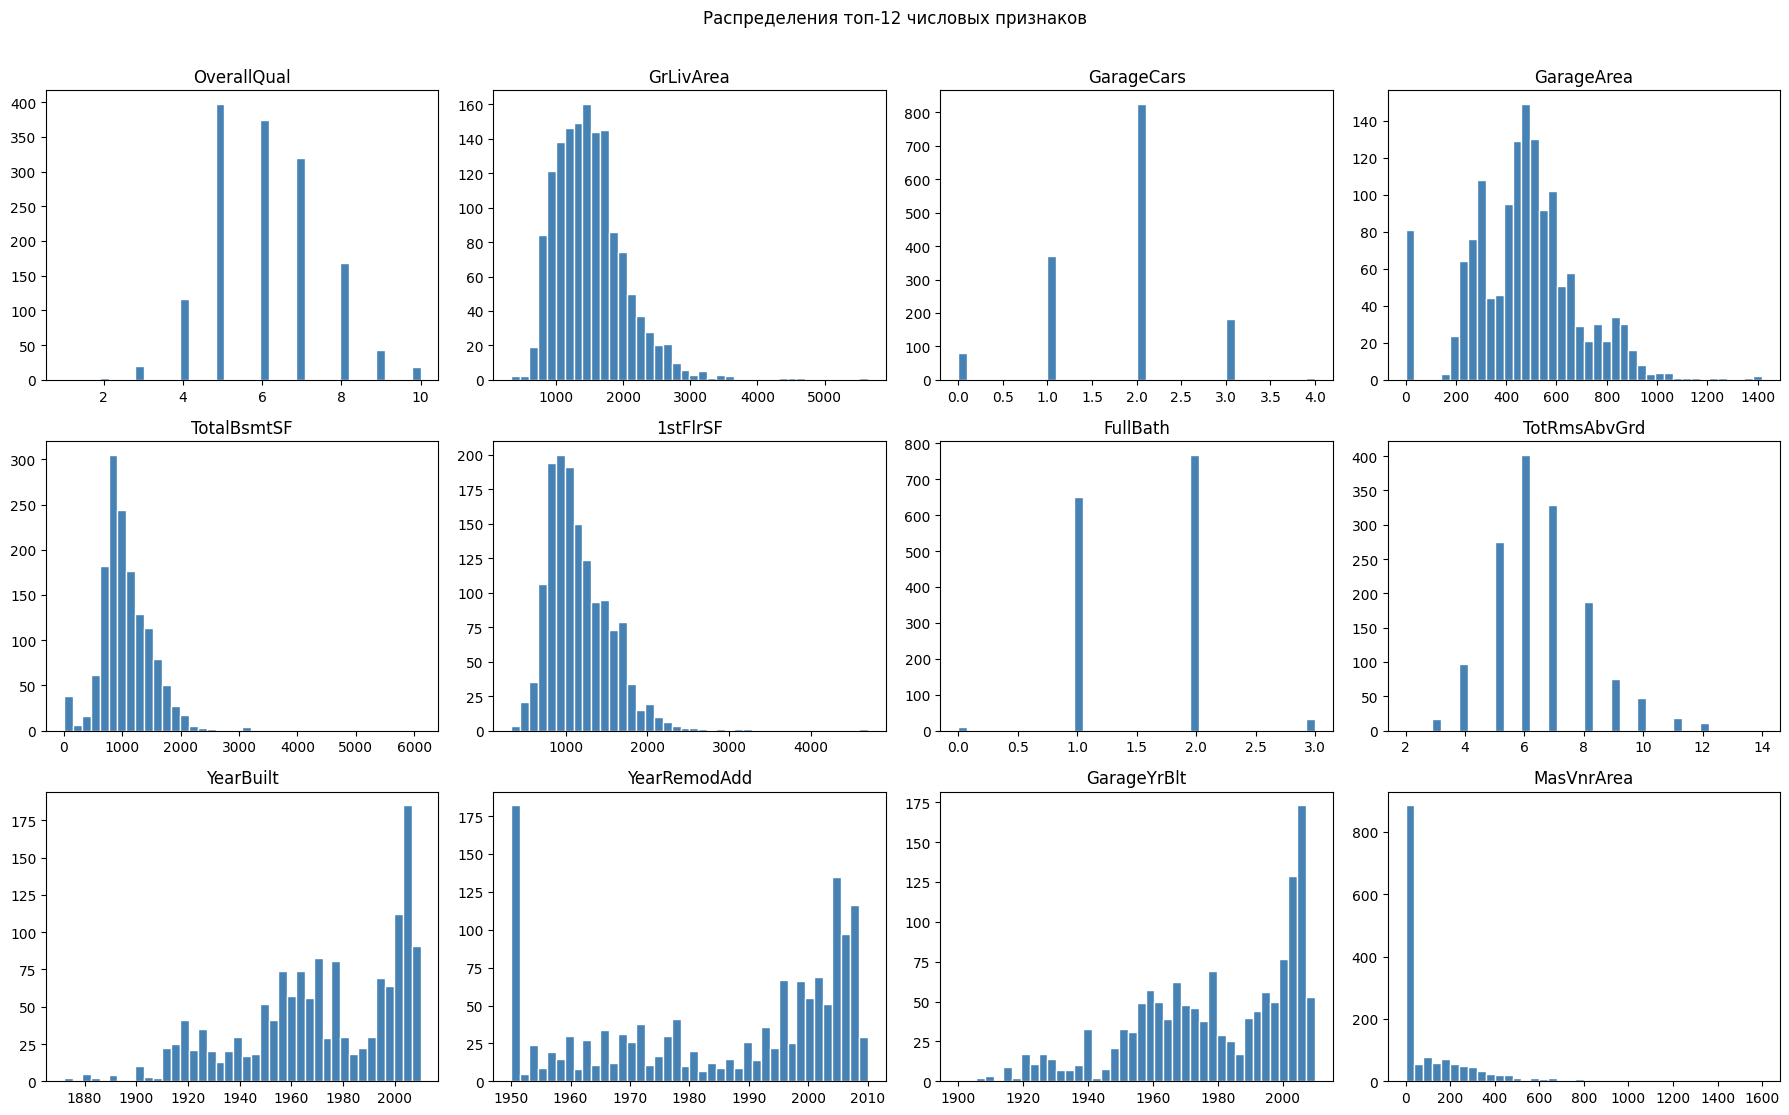

In [21]:
# Распределения топ-12 числовых признаков (по корреляции с SalePrice)
top12_num = (
    df.corr(numeric_only=True)['SalePrice']
    .drop('SalePrice').abs()
    .sort_values(ascending=False)
    .head(12).index
)

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for ax, col in zip(axes.flat, top12_num):
    ax.hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Распределения топ-12 числовых признаков', y=1.01)
plt.tight_layout()
plt.show()


## Итоги EDA

| Наблюдение | Решение в пайплайне |
|------------|---------------------|
| SalePrice скошен вправо | Обучение на `log1p(SalePrice)`, метрика RMSLE = RMSE |
| NaN = отсутствие объекта | `fill_na_domain()`: NaN → `"None"`/`0` |
| LotFrontage — пропуски по соседству | Медиана по `Neighborhood` |
| Выбросы GrLivArea > 4000 | Удаление в `load_data()` |
| Качественные признаки (Ex/Gd/TA...) | Ordinal encoding в `feature_engineering()` |
| Много скошенных числовых признаков | `log1p` в `log_skewed_features()` |
| OverallQual × GrLivArea — ключевые | Создан признак `Qual_x_Area` |
| Мультиколлинеарность площадей | Создан агрегат `TotalSF` |

Все эти решения реализованы в `features.py` и применяются одинаково для ML и DL.